# Aula Prática de Ciência de Dados: Prevendo Avaliações de Clientes em E-commerce

## Introdução: De Cliques a Avaliações - Prevendo o Engajamento do Cliente

A análise de dados em e-commerce transcendeu a simples contagem de vendas e o monitoramento de tráfego. No cenário competitivo atual, entender e antecipar o comportamento do cliente é um diferencial estratégico fundamental. O feedback do cliente, em particular, é um dos ativos mais valiosos para uma plataforma de comércio eletrônico. As avaliações de produtos não apenas influenciam as decisões de compra de outros consumidores, mas também fornecem dados cruciais para a otimização de catálogos, a melhoria de serviços e a construção de confiança na marca. A questão central para um negócio digital moderno não é apenas reativa — "Recebemos uma avaliação?" — mas proativa e preditiva: "Podemos prever quais transações têm maior probabilidade de gerar feedback?". A capacidade de responder a essa pergunta com precisão permite a criação de campanhas de marketing direcionadas, a otimização de fluxos de comunicação pós-venda e o desenvolvimento de funcionalidades na plataforma que incentivam o engajamento.

Para explorar esta questão, esta prática utilizará o *Brazilian E-Commerce Public Dataset by Olist*, um conjunto de dados robusto e do mundo real que detalha as operações de um dos maiores marketplaces do Brasil. O dataset contém informações de aproximadamente 100.000 pedidos realizados entre 2016 e 2018, abrangendo todo o ciclo de vida de uma transação: desde a compra inicial, passando pelo processamento do pagamento e envio, até, crucialmente, as avaliações deixadas pelos clientes. Esta riqueza de dados oferece um ambiente ideal para aplicar técnicas de ciência de dados e construir um modelo de aprendizado de máquina.

A jornada proposta nesta pratica foi desenhada especificamente para desenvolvedores, traçando um paralelo com o ciclo de vida de um projeto de software. Inicialmente, o papel será de um arquiteto de dados, responsável por compreender e conectar múltiplas fontes de dados. Em seguida, a transição será para a engenharia de dados, onde os dados brutos serão limpos, transformados e preparados para análise. Finalmente, o papel de um engenheiro de machine learning será assumido para construir, treinar e avaliar um modelo preditivo. Este percurso prático visa desmistificar o processo de ciência de dados, demonstrando como as habilidades de programação e lógica estruturada são a base para a criação de soluções inteligentes e orientadas a dados.

## Seção 1: Montando o Kit de Ferramentas - Configuração do Ambiente

Para garantir que todos os participantes possam acompanhar a prática de forma fluida e consistente, o primeiro passo é a configuração de um ambiente de desenvolvimento padronizado. A utilização de um ambiente virtual é uma prática recomendada em desenvolvimento de software para isolar as dependências de um projeto, evitando conflitos com outras instalações no sistema.

### 1.1. Instalando os Essenciais

As bibliotecas que formam o pilar da ciência de dados em Python serão instaladas. Cada uma desempenha um papel específico:
* **Pandas:** A ferramenta fundamental para manipulação e análise de dados tabulares.
* **Scikit-learn:** A principal biblioteca para aprendizado de máquina em Python, oferecendo algoritmos e ferramentas de avaliação.
* **Matplotlib & Seaborn:** Bibliotecas para visualização de dados, essenciais para a análise exploratória e a interpretação de resultados.
* **JupyterLab:** O ambiente de desenvolvimento interativo que será utilizado.

Os seguintes comandos devem ser executados no terminal para instalar estas bibliotecas. Recomenda-se fortemente a criação prévia de um ambiente virtual.

```bash
# Recomenda-se criar um ambiente virtual primeiro
# python -m venv meu_ambiente_ds
# source meu_ambiente_ds/bin/activate  (Em Mac/Linux)
# meu_ambiente_ds\Scripts\activate    (Em Windows)

pip install pandas scikit-learn matplotlib seaborn jupyterlab
```

### 1.2. Seu Laboratório Interativo: Jupyter & Google Colab

Diferente de um Ambiente de Desenvolvimento Integrado (IDE) tradicional, que executa um script inteiro de uma vez, os notebooks interativos como Jupyter e Google Colab são o padrão para a ciência de dados exploratória. Eles permitem uma "conversa" com os dados, onde o código é organizado em células que podem ser executadas de forma independente. Esta abordagem é ideal para o desenvolvimento iterativo, permitindo testar, visualizar e refinar a análise passo a passo.

* **Jupyter Notebook/Lab:** Uma aplicação web que permite criar e compartilhar documentos que contêm código ao vivo, equações, visualizações e texto narrativo.
* **Google Colab:** Uma alternativa baseada na nuvem que não requer instalação local e oferece acesso gratuito a recursos computacionais, sendo uma excelente opção para quem deseja começar imediatamente.

As operações fundamentais em um ambiente de notebook incluem a criação de novas células (tanto de código quanto de Markdown para documentação), a execução de células (comumente usando o atalho `Shift+Enter`), e o uso de células de Markdown para registrar o raciocínio e as conclusões ao longo do projeto.

### 1.3. Exercício 1: "Olá, Mundo da Ciência de Dados!"

Este primeiro exercício serve como uma verificação de sanidade para garantir que o ambiente de todos está configurado corretamente e que as bibliotecas foram instaladas com sucesso. A tarefa consiste em importar as bibliotecas essenciais e imprimir suas respectivas versões.

In [14]:
import pandas as pd
import sklearn
import matplotlib
import seaborn as sns

print(f"Versão do Pandas: {pd.__version__}")
print(f"Versão do Scikit-learn: {sklearn.__version__}")
print(f"Versão do Matplotlib: {matplotlib.__version__}")
print(f"Versão do Seaborn: {sns.__version__}")

Versão do Pandas: 2.2.2
Versão do Scikit-learn: 1.6.1
Versão do Matplotlib: 3.10.0
Versão do Seaborn: 0.13.2


## Seção 2: Primeiro Contato - Carregando e Explorando os Dados da Olist

Com o ambiente configurado, o próximo passo é carregar os dados brutos e realizar uma análise exploratória inicial (Exploratory Data Analysis - EDA). Esta fase é crucial para construir uma compreensão fundamental da estrutura, conteúdo e qualidade dos dados antes de qualquer tentativa de modelagem.

### 2.1. Carregando a Frota de Arquivos

O dataset da Olist não é um arquivo único, mas sim uma coleção de múltiplos arquivos CSV que se relacionam entre si, de forma análoga a um banco de dados relacional. Para o nosso objetivo, os arquivos mais relevantes serão carregados em DataFrames separados utilizando a função `pd.read_csv()` do Pandas, que é a porta de entrada para a manipulação de dados em Python.

In [15]:
# É uma boa prática armazenar os caminhos dos arquivos em variáveis
# Certifique-se de substituir './path/to/your/olist_data/' pelo caminho correto no seu sistema
DATA_PATH = './data/' # Altere este caminho se necessário

try:
    customers_df = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
    orders_df = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
    order_items_df = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
    order_reviews_df = pd.read_csv(DATA_PATH + 'olist_order_reviews_dataset.csv')
    products_df = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
    translation_df = pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')
    print("Arquivos carregados com sucesso!")
except FileNotFoundError:
    print("Erro: Arquivos não encontrados. Verifique o caminho em DATA_PATH.")
    print("Você pode baixar o dataset em: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce")

Arquivos carregados com sucesso!


### 2.2. Reconhecimento Inicial: O Trio `head`, `info` e `describe`

Antes de qualquer análise complexa, é imperativo realizar uma "verificação de saúde" nos dados. O Pandas oferece três funções essenciais para este diagnóstico inicial:

* `.head()`: Exibe as primeiras linhas do DataFrame, fornecendo uma amostra visual das colunas e dos tipos de valores que elas contêm.
* `.info()`: Oferece um resumo técnico conciso do DataFrame. Ele detalha os nomes das colunas, o número total de entradas, a contagem de valores não nulos por coluna e os tipos de dados (Dtypes). Esta função é a primeira ferramenta para identificar a presença de dados ausentes e tipos de dados inadequados (por exemplo, datas armazenadas como texto).
* `.describe()`: Para colunas numéricas, esta função calcula estatísticas descritivas chave, como média, mediana, desvio padrão, mínimo, máximo e os quartis. Isso ajuda a entender a distribuição e a escala dos dados, além de ser um primeiro indicador de possíveis outliers (valores extremos), como um produto com um preço anormalmente alto.

In [16]:
# Análise do DataFrame de Pedidos
print("--- DataFrame de Pedidos (orders_df) ---")
display(orders_df.head())
print("\n--- Informações Técnicas (info) ---")
orders_df.info()

# Análise do DataFrame de Itens do Pedido
print("\n--- Descrição Estatística (describe) do DataFrame de Itens ---")
display(order_items_df.describe())

--- DataFrame de Pedidos (orders_df) ---


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



--- Informações Técnicas (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

--- Descrição Estatística (describe) do DataFrame de Itens ---


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


### 2.3. Entendendo o Esquema

Desenvolvedores estão familiarizados com o conceito de esquemas de banco de dados. Este conhecimento pode ser aproveitado para entender as relações entre as tabelas da Olist. O passo mais importante aqui é identificar as chaves primárias e estrangeiras que conectam os diferentes arquivos. A chave `order_id` funciona como o elo central, conectando as tabelas de pedidos, itens de pedido e avaliações. Da mesma forma, `customer_id` liga os pedidos aos clientes, e `product_id` liga os itens de pedido aos produtos. Compreender essa estrutura é um pré-requisito indispensável para realizar as junções de dados corretamente.

A tabela a seguir fornece uma visão geral clara do esquema de dados, servindo como um guia de referência visual.

| DataFrame | Chave(s) Primária/Estrangeira | Descrição |
| :--- | :--- | :--- |
| `orders_df` | `order_id`, `customer_id` | Tabela principal com uma linha por pedido, ligando ao cliente. |
| `order_reviews_df` | `order_id`, `review_id` | Contém as pontuações e mensagens de avaliação para os pedidos que as possuem. |
| `order_items_df` | `order_id`, `product_id`, `seller_id` | Tabela de junção; um pedido pode conter múltiplos itens. |
| `customers_df` | `customer_id`, `customer_unique_id` | Contém dados de localização do cliente. |
| `products_df` | `product_id` | Contém a categoria, tamanho e peso do produto. |
| `translation_df` | `product_category_name` | Traduz os nomes das categorias de produtos de português para inglês. |

## Seção 3: Criando uma Visão Unificada - A Arte da Junção de Dados

Após a exploração inicial, o próximo objetivo é consolidar os DataFrames separados em um único e coeso conjunto de dados. Este DataFrame unificado conterá todas as informações necessárias para a análise e a subsequente construção do modelo.

### 3.1. Uma Estratégia de Junção Passo a Passo

A construção do DataFrame final será feita de forma incremental, utilizando `orders_df` como a base. Esta abordagem deliberada torna a lógica mais clara e facilita a depuração. A estratégia será:

1.  **Primeira Junção:** Combinar `orders_df` com `order_items_df` usando a chave `order_id`.
2.  **Segunda Junção:** Combinar o resultado com `products_df` usando a chave `product_id`.
3.  **Terceira Junção:** Adicionar os nomes das categorias em inglês a partir de `translation_df`.

Este processo sequencial garante que o conjunto de dados seja enriquecido de forma controlada e compreensível.

### 3.2. Explicando a Lógica da Junção

A escolha do tipo de junção (ou *join*) é uma das decisões mais críticas nesta fase. Para desenvolvedores familiarizados com SQL, os conceitos são diretamente transferíveis para o Pandas.

O objetivo do nosso modelo é prever se *qualquer* pedido receberá uma avaliação. Isso significa que o nosso conjunto de dados final deve, obrigatoriamente, conter *todos os pedidos* presentes no `orders_df` original. Se uma junção do tipo `inner join` (o padrão em `pd.merge`) fosse utilizada para combinar `orders_df` com `order_reviews_df`, o resultado conteria apenas os pedidos que possuem uma avaliação. Isso eliminaria instantaneamente todos os casos em que os clientes *não* deixaram uma avaliação, que são exatamente os casos que o modelo precisa aprender a diferenciar. Tal abordagem destruiria a base do problema de classificação.

Portanto, a única escolha correta ao adicionar informações ao nosso DataFrame base é o `left join`. Este tipo de junção mantém todas as linhas do DataFrame à esquerda (no nosso caso, `orders_df`) e adiciona as informações correspondentes do DataFrame à direita onde as chaves coincidem. Para as chaves que existem na esquerda mas não na direita, os valores das novas colunas são preenchidos com `NaN` (Not a Number). Essa abordagem garante a preservação do universo completo de pedidos, que é essencial para a nossa análise.

In [5]:
# Começando com a tabela de pedidos como base
merged_df = pd.merge(orders_df, order_items_df, on='order_id', how='left')
merged_df = pd.merge(merged_df, products_df, on='product_id', how='left')
merged_df = pd.merge(merged_df, translation_df, on='product_category_name', how='left')

print("Dimensões do DataFrame unificado:", merged_df.shape)
display(merged_df.head())

Dimensões do DataFrame unificado: (113425, 23)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


### 3.3. Exercício 2: Trazendo o Cliente para a Análise

Neste exercício, os participantes aplicarão o conceito de junção para enriquecer ainda mais o DataFrame. A tarefa é realizar uma junção adicional para incorporar as informações dos clientes, especificamente o estado (`customer_state`), do `customers_df` ao `merged_df`.

**Dica:** Será necessário identificar a chave de junção correta (`customer_id`) e utilizar o método `left join` para garantir que nenhum pedido seja perdido no processo.

In [18]:
merged_cs=pd.merge(merged_df, customers_df, on='customer_id', how='left')
print("Dimensões do DataFrame unificado:", merged_cs.shape)
display(merged_cs.head())

Dimensões do DataFrame unificado: (113425, 27)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,4.0,500.0,19.0,8.0,13.0,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,1.0,400.0,19.0,13.0,19.0,perfumery,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,1.0,420.0,24.0,19.0,21.0,auto,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,3.0,450.0,30.0,10.0,20.0,pet_shop,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,4.0,250.0,51.0,15.0,15.0,stationery,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


## Seção 4: Forjando as Features - Pré-processamento e Engenharia

Com um DataFrame unificado, a próxima fase é a de pré-processamento e engenharia de features. Este é o processo de limpar os dados, criar a variável alvo que o modelo irá prever, e transformar todas as variáveis (features) em um formato numérico que possa ser utilizado por um algoritmo de machine learning.

### 4.1. Lidando com as Lacunas: Dados Ausentes

A primeira etapa do pré-processamento é identificar e tratar valores ausentes. O comando `.isnull().sum()` é uma forma rápida e eficaz de contar os valores nulos em cada coluna do DataFrame.

Uma análise inicial dos dados ausentes no DataFrame unificado revelará muitos valores nulos em colunas como `order_approved_at`, `order_delivered_carrier_date` e `order_delivered_customer_date`. Uma abordagem ingênua seria simplesmente remover essas linhas ou preencher os valores ausentes. No entanto, uma investigação mais profunda da coluna `order_status` revela a verdadeira causa: pedidos com status `canceled` ou `unavailable` nunca terão datas de aprovação ou entrega. Os dados ausentes, neste caso, não são aleatórios, mas sim estruturais e esperados.

Para o nosso problema, não faz sentido prever se um cliente avaliará um pedido que nunca recebeu. Portanto, a decisão mais lógica e robusta é filtrar o conjunto de dados para incluir apenas os pedidos que foram efetivamente entregues (`order_status == 'delivered'`). Esta única ação resolve a maior parte do problema de dados ausentes e torna o objetivo do modelo muito mais claro e bem definido.

In [19]:
# Filtrar para manter apenas os pedidos com status 'delivered'
df = merged_df[merged_df['order_status'] == 'delivered'].copy()

# Agora, verificar novamente os valores ausentes
print("Contagem de valores ausentes após filtrar por 'delivered':")
print(df.isnull().sum())

# É provável que ainda existam alguns valores ausentes em colunas como
# product_category_name_english ou dimensões do produto.
# Para simplificar nesta pratica, removeremos as linhas com dados ausentes
# nas colunas que usaremos como features.
df.dropna(subset=['product_category_name_english', 'price', 'freight_value'], inplace=True)

Contagem de valores ausentes após filtrar por 'delivered':
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date        2
order_delivered_customer_date       8
order_estimated_delivery_date       0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name            1537
product_name_lenght              1537
product_description_lenght       1537
product_photos_qty               1537
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
product_category_name_english    1559
dtype: int64


### 4.2. A Tarefa Central: Criando a Variável Alvo `deixou_review`

Este é o passo de engenharia de features mais crítico do projeto. O objetivo é criar uma nova coluna, a nossa variável alvo (target), que seja `True` se um pedido tiver uma avaliação associada e `False` caso contrário.

Embora seja possível realizar um `left join` do DataFrame principal com o `order_reviews_df` e depois verificar a presença de `NaN` na coluna `review_score`, o Pandas oferece uma solução mais direta e elegante: o parâmetro `indicator=True` na função `pd.merge`. Ao usar este parâmetro em um `left join`, o Pandas adiciona uma coluna especial chamada `_merge`. O valor nesta coluna será `'both'` se a chave do pedido for encontrada em ambos os DataFrames (ou seja, o pedido tem uma avaliação) e `'left_only'` se a chave existir apenas no DataFrame da esquerda (o pedido não tem uma avaliação). Esta coluna `_merge` fornece diretamente a informação necessária, permitindo a criação da variável alvo de forma limpa, explícita e menos suscetível a erros.

In [20]:
# Para a verificação, precisamos apenas do 'order_id' da tabela de avaliações
reviews_check_df = order_reviews_df[['order_id']].drop_duplicates()

# Realiza o left merge com o parâmetro 'indicator'
df = pd.merge(df, reviews_check_df, on='order_id', how='left', indicator=True)

# Cria a variável alvo booleana a partir da coluna '_merge'
df['deixou_review'] = (df['_merge'] == 'both')

# Remove a coluna '_merge' que já cumpriu seu propósito
df.drop('_merge', axis=1, inplace=True)

# Verifica a distribuição da nova variável alvo
# O parâmetro normalize=True mostra as proporções em vez da contagem bruta
print("Distribuição da variável alvo 'deixou_review':")
print(df['deixou_review'].value_counts(normalize=True))

Distribuição da variável alvo 'deixou_review':
deixou_review
True     0.992498
False    0.007502
Name: proportion, dtype: float64


### 4.3. Seleção de Features

A seleção de features é o processo de escolher as variáveis de entrada (`features`) que serão usadas para prever a variável alvo. Para esta prática, será utilizado um conjunto inicial simples e intuitivo, baseado em hipóteses de negócio testáveis:
* **Features Selecionadas:** `price`, `freight_value`, `product_category_name_english`.
* **Justificativa:** Estas features permitem investigar se o preço do produto, o custo do frete ou a categoria do produto influenciam a probabilidade de um cliente deixar uma avaliação. Por exemplo, clientes podem ser mais propensos a avaliar produtos de maior valor ou de categorias específicas como eletrônicos.

### 4.4. De Categorias a Números: One-Hot Encoding

Os modelos de machine learning são, em essência, funções matemáticas e, portanto, exigem entradas numéricas. Não é possível alimentar um modelo com o texto `'health_beauty'`. A técnica padrão para converter variáveis categóricas em um formato numérico é o **One-Hot Encoding**. A função `pd.get_dummies` do Pandas implementa essa técnica, criando novas colunas binárias (com valores 0 ou 1) para cada categoria única presente na coluna original. Por exemplo, a coluna `product_category_name_english` será transformada em múltiplas colunas como `category_health_beauty`, `category_computers_accessories`, etc..

In [8]:
# Seleciona as features e a variável alvo
features = ['price', 'freight_value', 'product_category_name_english']
target = 'deixou_review'

X = df[features]
y = df[target]

# Aplica o One-Hot Encoding na coluna categórica
# drop_first=True remove a primeira categoria para evitar multicolinearidade, uma boa prática
X_encoded = pd.get_dummies(X, columns=['product_category_name_english'], drop_first=True)

print("Dimensões de X antes do encoding:", X.shape)
print("Dimensões de X após o encoding:", X_encoded.shape)
display(X_encoded.head())

Dimensões de X antes do encoding: (108638, 3)
Dimensões de X após o encoding: (108638, 72)


,price,freight_value,product_category_name_english_air_conditioning,product_category_name_english_art,product_category_name_english_arts_and_craftmanship,product_category_name_english_audio,product_category_name_english_auto,product_category_name_english_baby,product_category_name_english_bed_bath_table,product_category_name_english_books_general_interest,...,product_category_name_english_security_and_services,product_category_name_english_signaling_and_security,product_category_name_english_small_appliances,product_category_name_english_small_appliances_home_oven_and_coffee,product_category_name_english_sports_leisure,product_category_name_english_stationery,product_category_name_english_tablets_printing_image,product_category_name_english_telephony,product_category_name_english_toys,product_category_name_english_watches_gifts
0,29.99,8.72,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,118.70,22.76,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,159.90,19.22,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,45.00,27.20,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,19.90,8.72,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


### 4.5. Exercício 3: Engenharia de uma Nova Feature

Neste exercício, os participantes são desafiados a criar uma nova feature chamada `delivery_time` (tempo de entrega). Esta tarefa consolida várias habilidades de manipulação de dados.

**Tarefa:** Calcular a diferença em dias entre a data da compra (`order_purchase_timestamp`) e a data de entrega ao cliente (`order_delivered_customer_date`).

**Dica:** Primeiro, as colunas de data (que estão como texto) devem ser convertidas para o tipo `datetime` usando `pd.to_datetime()`. Em seguida, a subtração das duas colunas resultará em um objeto `Timedelta`, que pode ser convertido para dias acessando o atributo `.dt.days`.

## Seção 5: Treinando o Classificador - Construindo um Modelo de Regressão Logística

Com os dados devidamente preparados e as features transformadas, o projeto entra na fase de modelagem. Esta seção introduz os conceitos centrais de treinamento de um modelo de machine learning, incluindo a divisão dos dados em conjuntos de treino e teste e a aplicação do algoritmo de Regressão Logística.

### 5.1. A Regra de Ouro: Divisão em Treino e Teste

O conceito mais fundamental na avaliação de modelos é que um modelo não pode ser testado com os mesmos dados que foram usados para seu treinamento. Fazer isso seria análogo a aplicar uma prova a um aluno com as mesmas questões que ele usou para estudar; o resultado mediria apenas a capacidade de memorização, não o aprendizado real. Este fenômeno é conhecido como **overfitting** (sobreajuste), onde o modelo se torna excessivamente especializado nos dados de treino e perde a capacidade de generalizar para dados novos e inéditos.

Para evitar isso, o conjunto de dados é dividido aleatoriamente em um conjunto de treino (geralmente 70-80% dos dados) e um conjunto de teste (os 20-30% restantes). O modelo aprenderá os padrões apenas com o conjunto de treino. O conjunto de teste será mantido "secreto" até o final, servindo como uma simulação de dados do mundo real para uma avaliação imparcial do desempenho do modelo. A função `train_test_split` da biblioteca Scikit-learn é a ferramenta padrão para realizar essa divisão.

É crucial notar o uso do parâmetro `stratify=y`. Em problemas com classes desbalanceadas, como o nosso, este parâmetro garante que a proporção de `True` e `False` na variável alvo seja a mesma tanto no conjunto de treino quanto no de teste, evitando que um dos conjuntos tenha uma representação enviesada das classes.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("Dimensões do conjunto de treino:", X_train.shape)
print("Dimensões do conjunto de teste:", X_test.shape)

Dimensões do conjunto de treino: (86910, 72)
Dimensões do conjunto de teste: (21728, 72)


### 5.2. Uma Introdução Intuitiva à Regressão Logística

Apesar do nome, a Regressão Logística é um algoritmo de classificação, não de regressão. Seu objetivo é prever um resultado binário (0 ou 1, `False` ou `True`). O funcionamento do modelo pode ser entendido em um processo de duas etapas:

1.  **Combinação Linear:** Primeiramente, o modelo calcula uma pontuação (score) através de uma soma ponderada das features de entrada, de forma idêntica à regressão linear. A equação é $z = w_1 \times \text{price} + w_2 \times \text{freight_value} + \dots + b$, onde os $w$ são os pesos (coeficientes) e $b$ é o bias (intercepto). O resultado $z$ pode ser qualquer número real, positivo ou negativo.

2.  **A Transformação Sigmoide:** Em seguida, essa pontuação $z$ é passada por uma função de ativação especial em forma de "S", conhecida como **função Sigmoide** ou **função Logística**.

A propriedade fundamental da função Sigmoide é que ela "esmaga" qualquer número de entrada em um valor de saída que está sempre entre 0 e 1. Este valor de saída pode ser interpretado diretamente como uma probabilidade. Por convenção, se a probabilidade resultante for maior que 0.5, o modelo classifica a instância como 1 (neste caso, `deixou_review = True`); caso contrário, classifica como 0.

![Função Sigmoide](https://developers.google.com/static/machine-learning/crash-course/logistic-regression/images/sigmoid_function_with_axes.png?hl=pt-br)

### 5.3. A Fase de Aprendizagem: `.fit()`

O processo de "treinamento" do modelo é executado pelo método `.fit()`. Ao chamar este método, o algoritmo de Regressão Logística utiliza os dados de treino (`X_train` e `y_train`) para encontrar os valores ótimos para os pesos ($w$) e o bias ($b$). O objetivo do algoritmo é encontrar os parâmetros que melhor mapeiam as features de entrada para a variável alvo, geralmente minimizando uma função de custo como a entropia cruzada.

In [10]:
from sklearn.linear_model import LogisticRegression

# Instancia o modelo com alguns parâmetros
# max_iter=1000 garante que o algoritmo tenha iterações suficientes para convergir
# random_state=42 garante a reprodutibilidade dos resultados
model = LogisticRegression(max_iter=1000, random_state=42)

# Treina o modelo utilizando os dados de treino
model.fit(X_train, y_train)

print("Treinamento do modelo concluído.")

Treinamento do modelo concluído.


## Seção 6: Julgando o Desempenho - Avaliação do Modelo

Com o modelo treinado, a etapa final é avaliar seu desempenho. Esta avaliação deve ser feita exclusivamente no conjunto de teste (`X_test` e `y_test`), que o modelo nunca viu durante o treinamento. Esta seção aborda como fazer previsões e introduz métricas de avaliação robustas que vão além da simples acurácia.

### 6.1. Fazendo Previsões: `.predict()`

O método `.predict()` é usado para aplicar o modelo treinado aos dados de teste. Para cada linha em `X_test`, o modelo calculará a probabilidade de o cliente deixar uma avaliação e, com base no limiar de 0.5, retornará uma previsão final de `True` ou `False`.

In [11]:
# Faz previsões no conjunto de teste
y_pred = model.predict(X_test)

### 6.2. A Primeira Métrica: Acurácia

A acurácia é a métrica de avaliação mais intuitiva: ela mede a proporção de previsões que o modelo acertou. É calculada como (Número de Previsões Corretas) / (Número Total de Previsões).

No entanto, a acurácia pode ser perigosamente enganosa, especialmente em conjuntos de dados com classes desbalanceadas. Como identificado na Seção 4.2, a grande maioria dos pedidos no nosso dataset possui uma avaliação (a classe `True` é dominante). Um modelo "ingênuo" que simplesmente previsse `True` para todos os pedidos alcançaria uma acurácia muito alta (por exemplo, 98%), mas não teria aprendido absolutamente nada sobre os padrões nos dados. Ele seria inútil na prática para identificar os poucos casos em que um cliente *não* deixa uma avaliação. Este fenômeno, conhecido como o **paradoxo da acurácia**, demonstra a lição mais importante na avaliação de classificadores: uma alta acurácia não implica, necessariamente, um bom modelo. É preciso uma ferramenta mais detalhada para entender *como* o modelo está acertando e errando.

In [12]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do Modelo: {accuracy:.4f}")

Acurácia do Modelo: 0.9925


### 6.3. Além da Acurácia: A Matriz de Confusão

A Matriz de Confusão é a ferramenta que resolve o paradoxo da acurácia. Em vez de um único número, ela é uma tabela que detalha o desempenho do classificador, mostrando não apenas *quantas* previsões estavam erradas, mas também *o tipo* de erro que foi cometido. Para um problema de classificação binária, a matriz tem um formato 2x2.

A tabela a seguir define os quatro quadrantes da matriz no contexto do nosso problema.

| | **Previsto: Não Deixou Review (0)** | **Previsto: Deixou Review (1)** |
| :--- | :--- | :--- |
| **Real: Não Deixou Review (0)** | **Verdadeiro Negativo (TN)** <br> Previsão correta de que não haveria review. | **Falso Positivo (FP)** <br> Erro: previu um review que não aconteceu. (Erro Tipo I) |
| **Real: Deixou Review (1)** | **Falso Negativo (FN)** <br> Erro: não previu um review que de fato aconteceu. (Erro Tipo II) | **Verdadeiro Positivo (TP)** <br> Previsão correta de que haveria um review. |

A análise da matriz de confusão, especialmente dos valores fora da diagonal principal (FP e FN), fornece uma visão muito mais rica do comportamento do modelo. A visualização da matriz como um mapa de calor (heatmap) facilita a interpretação.

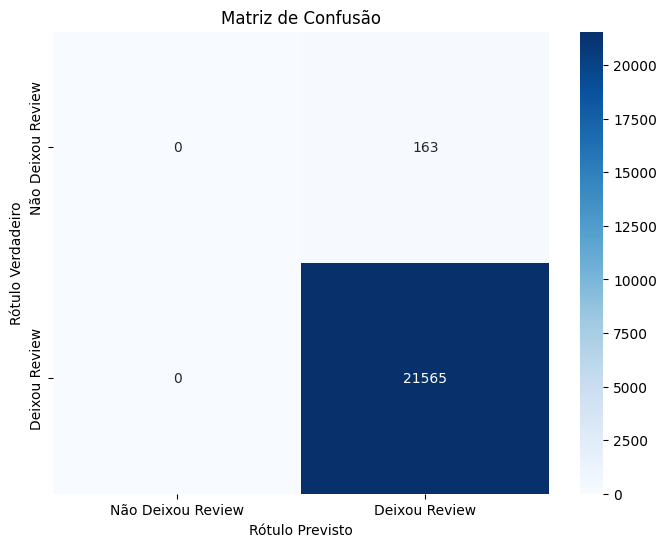

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Deixou Review', 'Deixou Review'],
            yticklabels=['Não Deixou Review', 'Deixou Review'])
plt.xlabel('Rótulo Previsto')
plt.ylabel('Rótulo Verdadeiro')
plt.title('Matriz de Confusão')
plt.show()

### 6.4. Exercício 4: Calcular Precisão e Recall

A partir dos valores da matriz de confusão (TP, FP, FN, TN), é possível calcular métricas mais específicas. Neste exercício, os participantes calcularão duas das mais importantes:

* **Precisão (Precision):** Das vezes em que o modelo previu que um cliente deixaria uma avaliação, quantas vezes ele estava certo? A precisão foca na qualidade das previsões positivas.
    * Fórmula: $Precisão = \frac{TP}{TP + FP}$
* **Recall (Revocação ou Sensibilidade):** De todos os clientes que de fato deixaram uma avaliação, quantos o modelo conseguiu identificar corretamente? O recall foca na capacidade do modelo de encontrar todos os casos positivos.
    * Fórmula: $Recall = \frac{TP}{TP + FN}$

A tarefa é calcular essas duas métricas manualmente usando os valores da matriz de confusão gerada e discutir o que cada uma significa no contexto do problema de negócio.

## Desafio Final: Uma Nova Fronteira - Prevendo Fraude em Cartão de Crédito

Para consolidar todas as habilidades adquiridas durante a prática, este desafio final propõe a aplicação do fluxo de trabalho completo a um novo e independente problema de classificação.

### O Cenário

O novo problema é um clássico da ciência de dados: a detecção de fraude em transações de cartão de crédito. Este caso de uso é uma excelente continuação, pois também envolve um conjunto de dados altamente desbalanceado, reforçando as lições aprendidas sobre a importância de métricas de avaliação adequadas, como a matriz de confusão.

### O Dataset

Será utilizado o dataset "Credit Card Fraud Detection", disponível publicamente na plataforma Kaggle. Este conjunto de dados contém transações anonimizadas, onde as features são componentes principais (resultado de uma transformação PCA) para proteger a privacidade dos dados. A coluna mais importante é a `Class`, que indica se uma transação foi fraudulenta (valor 1) ou legítima (valor 0).

https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

### A Tarefa

Os participantes devem desenvolver um notebook Jupyter que aplique todo o fluxo de trabalho aprendido nesta prática a este novo dataset. O objetivo é construir e avaliar um modelo de Regressão Logística para detectar transações fraudulentas.

### O Entregável

Um notebook Jupyter limpo e bem comentado que execute os seguintes passos:
1.  **Carregamento e Exploração:** Carregar o dataset de fraude e usar `.info()`, `.describe()` e `.head()` para entender sua estrutura. Verificar a distribuição da variável alvo `Class`.
2.  **Seleção de Features:** Como as features já são numéricas e anonimizadas, esta etapa é mais simples. Todas as colunas de `V1` a `V28`, além de `Amount`, podem ser usadas como features.
3.  **Divisão dos Dados:** Dividir os dados em conjuntos de treino e teste, lembrando de usar a estratificação (`stratify`) devido ao grande desequilíbrio de classes.
4.  **Treinamento do Modelo:** Instanciar e treinar um modelo de `LogisticRegression` com os dados de treino.
5.  **Avaliação do Modelo:**
    * Calcular a **Acurácia** do modelo no conjunto de teste.
    * Gerar e visualizar a **Matriz de Confusão**.
6.  **Análise e Conclusão:** Incluir uma célula de Markdown no final do notebook explicando:
    * Por que a acurácia é uma métrica particularmente ruim para este problema de detecção de fraude.
    * O que a matriz de confusão revela sobre o desempenho do modelo. Especificamente, quantos casos de fraude (Falsos Negativos) o modelo deixou de detectar e quantas transações legítimas ele classificou incorretamente como fraude (Falsos Positivos).